# 05 : Reinforcement Learning: Next-Best-Action Policy
### Tabular Q-Learning vs. Deep Q-Network (DQN)

---

**Project pipeline (this notebook is stage 5 of 5 — the final stage):**

| Stage | Notebook | Purpose |
|---|---|---|
| 1 | `01_data_preprocessing.ipynb` | Load, clean, engineer `customer_features.csv` |
| 2 | `02_pca_lda.ipynb` | Split customers, label `HighValue`, standardize, PCA/LDA |
| 3 | `03_classification.ipynb` | Predict `HighValue` (binary classifier) |
| 4 | `04_regression.ipynb` | Predict `NextQuarterSpend` (the revenue simulator) |
| 5 | **`05_qlearning_dqn.ipynb`** ⬅ *you are here* | Learn a **next-best-action policy**: for each customer, which intervention maximizes expected reward? |

## The business problem, framed as reinforcement learning

We want a policy that looks at a customer's profile and recommends **one of three interventions**:

| Action | Meaning | Cost | Conversion multiplier |
|---|---|---|---|
| **0** | No outreach | \$0 | ×0.30 |
| **1** | Email / small discount | \$1 | ×0.55 |
| **2** | Phone call / large incentive | \$5 | ×0.75 |

**Reward** for a given customer and action is:
$$\text{reward} = (\text{predicted next-quarter spend}) \times (\text{conversion multiplier}) - (\text{cost})$$

The intuition: a more expensive/aggressive intervention (Action 2) converts a larger share of the customer's predicted spend into realized revenue, but costs more to execute. The policy's job is to learn **which action is worth it for which kind of customer** — a low-predicted-spend customer might not be worth a \$5 phone call, while a high-predicted-spend customer might be.

**State** = the same 5 standardized category-spend-% features used throughout notebooks 02–04 (`Homeware_Pct`, `Stationery_Pct`, `Gadgets_Pct`, `Decorations_Pct`, `Kitchenware_Pct`). **This is deliberate**: it means the state the RL agent observes is exactly the feature vector `04_regression.ipynb`'s champion regressor was trained on, so `regressor.predict(state)` is always a valid, in-distribution call.

## ⚠️ An important modeling caveat, upfront

This notebook sets `next_state = current_state` after every action (see the training loop comments). That means **there is no real state transition** — taking an action doesn't change what "state" a customer is in for a hypothetical next step. Structurally, this makes the problem a **contextual bandit** (one-shot decision per customer, informed by context) rather than a true multi-step Markov Decision Process. We still call it "reinforcement learning" and use Q-learning/DQN machinery, because:
- It's a legitimate, common simplification when there's no natural multi-step customer journey to model yet (that would require, e.g., simulating how spend behavior changes *after* an intervention — data we don't have).
- The Q-learning and DQN machinery still works correctly on a bandit problem; the Bellman equation's `γ · max Q(s', a')` term just ends up bootstrapping off the *same* state's own value, which the code below still computes correctly.

Understanding this distinction matters if you extend this notebook later — e.g. if you eventually get real "spend behavior in the quarter *after* an intervention" data, that's when `next_state` should genuinely differ from `current_state`, turning this into true multi-step RL.

## Two policies compared, same as the model-family comparisons in notebooks 03–04

1. **Tabular Q-Learning** — discretizes the continuous 5D state into 8 clusters (via K-Means) and learns a small `8 × 3` lookup table of action-values. Simple, fast, fully inspectable — but loses information every time two genuinely different customers land in the same cluster.
2. **Deep Q-Network (DQN)** — a small neural network learns `Q(state, action)` directly from the continuous 5D state, with no discretization. Can in principle represent much finer-grained policies, at the cost of being a black box and needing more careful training (replay buffer, target network) to stay stable.

## 📦 Prerequisites & Data Lineage Check

Just like notebooks 03 and 04, this notebook runs in its **own kernel** — it cannot see any variable from earlier notebooks unless that notebook wrote it to disk. We load real files here rather than relying on `'train_customers' not in locals()` fallback logic (a check that, run standalone, *always* evaluates to "not found" — meaning the original version of this notebook would silently use synthetic data 100% of the time, never real data).

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import deque

from sklearn.cluster import KMeans

# Suppress a harmless KMeans thread-oversubscription warning on some platforms
os.environ["OMP_NUM_THREADS"] = "5"

# Deterministic seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["font.size"] = 10

DATA_DIR = "../data"
FEATURE_COLS = ["Homeware_Pct", "Stationery_Pct", "Gadgets_Pct", "Decorations_Pct", "Kitchenware_Pct"]

print("Setup complete.")

Setup complete.


In [2]:
# ==========================================================================
# Pinpoint check: do the expected input files exist? (Notebook Relative Paths)
# ==========================================================================
# Look one level up (..) to find data and models from the notebooks directory
NOTEBOOK_DATA_DIR = os.path.join("..", "data")
NOTEBOOK_MODEL_DIR = os.path.join("..", "models")

required_files = {
    os.path.join(NOTEBOOK_DATA_DIR, "train_split.csv"): "customer-level training split (from 02_pca_lda.ipynb)",
    os.path.join(NOTEBOOK_DATA_DIR, "val_split.csv"):   "customer-level validation split",
    os.path.join(NOTEBOOK_DATA_DIR, "test_split.csv"):  "customer-level test split",
    os.path.join(NOTEBOOK_MODEL_DIR, "champion_regressor.pkl"): "trained revenue simulator (from 04_regression.ipynb)",
}

missing = []
for fpath, description in required_files.items():
    exists = os.path.exists(fpath)
    marker = "\u2705" if exists else "\u274C"
    print(f"{marker} {fpath:<45} {'FOUND' if exists else 'MISSING'}  -- {description}")
    if not exists:
        missing.append(fpath)

USING_FALLBACK_DATA = len(missing) > 0
if USING_FALLBACK_DATA:
    print("\n\u26A0\uFE0F  One or more real input files are missing. This notebook will fall back to")
    print("    FULLY SYNTHETIC customers and a dummy regressor, purely so its mechanics can still")
    print("    run end-to-end. Metrics in that mode are NOT meaningful -- see Section 1 below.")
else:
    print("\nAll required input files found. Loading real data.")

✅ ..\data\train_split.csv                       FOUND  -- customer-level training split (from 02_pca_lda.ipynb)
✅ ..\data\val_split.csv                         FOUND  -- customer-level validation split
✅ ..\data\test_split.csv                        FOUND  -- customer-level test split
✅ ..\models\champion_regressor.pkl              FOUND  -- trained revenue simulator (from 04_regression.ipynb)

All required input files found. Loading real data.


## 1. Load Real Customers & the Revenue Simulator

We load the three customer splits and the champion regressor trained in `04_regression.ipynb`. We also check that regressor's saved metadata for the `used_synthetic_surrogate_target` flag notebook 04 recorded — if the revenue simulator itself was trained on a synthetic surrogate target, every reward this RL agent learns from is, transitively, also synthetic. We surface that clearly rather than burying it.

**On `state` vs. `features`:** the original version of this notebook's `MockCustomer` used two *unrelated* random vectors for `state` (fed to K-Means/DQN) and `features` (fed to the regressor) — for a real customer these must be the **same underlying profile**, otherwise the agent would be learning a policy for one customer's shopping pattern while predicting revenue for a completely different, unrelated pattern. We fix this: `state == features` == the customer's 5 category-spend-% values, always.

In [3]:
class Customer:
    '''A single customer's state/feature vector (identical) plus predicted spend, precomputed once.'''
    __slots__ = ("customer_id", "state", "features", "pred_spend", "cluster")

    def __init__(self, cid, feature_vector):
        self.customer_id = cid
        self.state = np.asarray(feature_vector, dtype=np.float64)
        self.features = self.state  # same vector: see markdown above
        self.pred_spend = None  # filled in after the regressor is loaded
        self.cluster = None     # filled in after KMeans is fit


def load_customers_from_split(csv_path, feature_cols):
    df = pd.read_csv(csv_path, index_col="CustomerID")
    return [Customer(cid, row[feature_cols].to_numpy()) for cid, row in df.iterrows()], df


if not USING_FALLBACK_DATA:
    # Look up into the standalone root data/ directory
    NOTEBOOK_DATA_DIR = os.path.join("..", "data")
    NOTEBOOK_MODEL_DIR = os.path.join("..", "models")

    train_customers, train_df = load_customers_from_split(os.path.join(NOTEBOOK_DATA_DIR, "train_split.csv"), FEATURE_COLS)
    val_customers, val_df     = load_customers_from_split(os.path.join(NOTEBOOK_DATA_DIR, "val_split.csv"),   FEATURE_COLS)
    test_customers, test_df   = load_customers_from_split(os.path.join(NOTEBOOK_DATA_DIR, "test_split.csv"),  FEATURE_COLS)

    # Load the champion regressor from the standalone root models/ directory
    regressor = joblib.load(os.path.join(NOTEBOOK_MODEL_DIR, "champion_regressor.pkl"))

    reg_meta_path = os.path.join(NOTEBOOK_MODEL_DIR, "champion_regressor_metadata.json")
    reg_meta = json.load(open(reg_meta_path)) if os.path.exists(reg_meta_path) else {}
    USING_SYNTHETIC_REWARD_BASIS = bool(reg_meta.get("used_synthetic_surrogate_target", False))

    print(f"✅ Loaded {len(train_customers)} train / {len(val_customers)} val / {len(test_customers)} test real customers.")
    print(f"✅ Loaded champion regressor: {reg_meta.get('champion_name', 'unknown')}")
    if USING_SYNTHETIC_REWARD_BASIS:
        print("⚠️  reg_meta['used_synthetic_surrogate_target'] = True")
        print("   Every reward this notebook computes is downstream of a SYNTHETIC revenue target.")
        print("   Treat all reward/policy numbers below as a MECHANICS DEMONSTRATION, not real business results.")
else:
    print("⚠️ Generating fully synthetic customers and a dummy regressor (fallback mode).")
    rng = np.random.default_rng(RANDOM_STATE)

    def _make_synthetic(n):
        feats = rng.uniform(0, 100, size=(n, 5))
        feats = feats / feats.sum(axis=1, keepdims=True) * 100  # roughly percentage-like
        return [Customer(i, feats[i]) for i in range(n)]

    train_customers = _make_synthetic(800)
    val_customers = _make_synthetic(120)
    test_customers = _make_synthetic(120)

    class FallbackRegressor:
        _weights = np.array([120.0, 200.0, 450.0, 90.0, 250.0])  # one weight per FEATURE_COLS entry

        def predict(self, X):
            X = np.asarray(X)
            return np.clip(X @ self._weights / 100 * 3.5 + 120, 10, 4500)

    regressor = FallbackRegressor()
    USING_SYNTHETIC_REWARD_BASIS = True

train_states = np.array([c.state for c in train_customers])
print(f"\nTraining States Matrix Shape: {train_states.shape}")

✅ Loaded 2892 train / 362 val / 362 test real customers.
✅ Loaded champion regressor: Model 1 (MLPRegressor)

Training States Matrix Shape: (2892, 5)


### 🔍 Before Training — Precompute Predicted Spend (correctness *and* a major speed-up)

**Key insight:** `pred_spend` for a customer depends only on that customer's `features` — never on the RL episode, the action taken, or training progress. The original loop called `regressor.predict([cust.features])` *inside* the innermost loop, once per customer **per episode** (500 episodes × N customers = potentially hundreds of thousands of redundant, identical predictions for the same customer). We compute it **once per customer, up front**, with a single vectorized call — this is a pure efficiency refactor with **zero change in behavior or results**, since the value is deterministic and constant across episodes.

In [4]:
# ==========================================
# Precompute predicted spend ONCE per customer (not per episode)
# ==========================================
for split_name, customers in [("train", train_customers), ("val", val_customers), ("test", test_customers)]:
    feats = np.array([c.features for c in customers])
    preds = regressor.predict(feats)
    for c, p in zip(customers, preds):
        c.pred_spend = float(p)
    print(f"Precomputed pred_spend for {len(customers):,} {split_name} customers "
          f"(mean=\u0024{np.mean(preds):,.2f}, min=\u0024{np.min(preds):,.2f}, max=\u0024{np.max(preds):,.2f})")

Precomputed pred_spend for 2,892 train customers (mean=$665.25, min=$-694.18, max=$1,560.01)
Precomputed pred_spend for 362 val customers (mean=$651.15, min=$-221.84, max=$1,255.70)
Precomputed pred_spend for 362 test customers (mean=$653.84, min=$-361.22, max=$1,300.76)


### 🔍 Before Training — What does the customer population actually look like?

A quick look at the predicted-spend distribution across our training population. This matters for interpreting the policy later: if predicted spend is tightly clustered, we'd expect the learned policy to mostly pick one action; if it's spread out, we'd expect the policy to meaningfully differentiate.

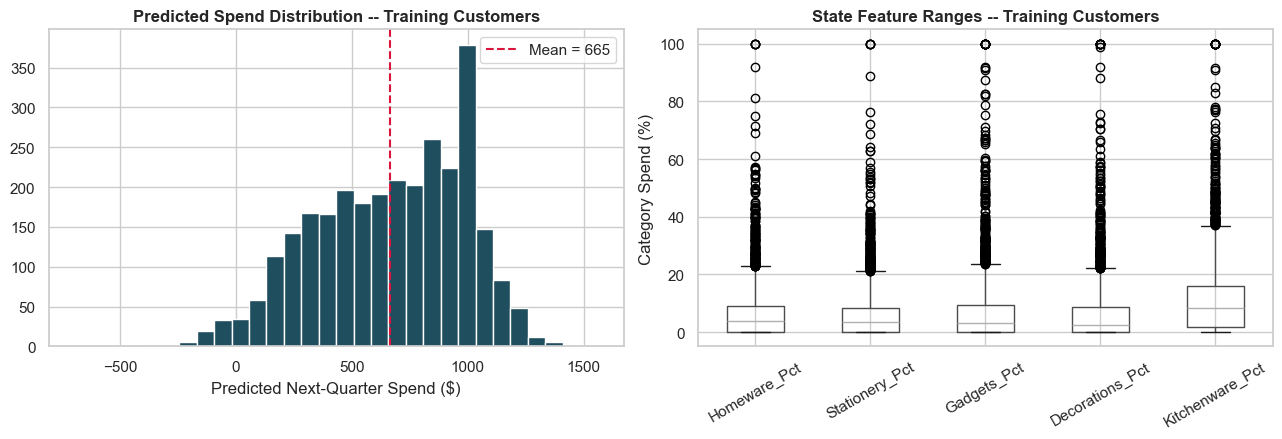

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

train_pred_spend = np.array([c.pred_spend for c in train_customers])
axes[0].hist(train_pred_spend, bins=30, color="#1F4E5F", edgecolor="white")
axes[0].axvline(train_pred_spend.mean(), color="crimson", linestyle="--", label=f"Mean = {train_pred_spend.mean():.0f}")
axes[0].set_title("Predicted Spend Distribution -- Training Customers", fontweight="bold")
axes[0].set_xlabel("Predicted Next-Quarter Spend ($)")
axes[0].legend()

pd.DataFrame(train_states, columns=FEATURE_COLS).boxplot(ax=axes[1])
axes[1].set_title("State Feature Ranges -- Training Customers", fontweight="bold")
axes[1].set_ylabel("Category Spend (%)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

---
## 2. The Reward Function

The reward formula, exactly as designed: for a given predicted spend and chosen action, apply that action's conversion multiplier and subtract its execution cost.

In [6]:
PROB_ADJ = {0: 0.30, 1: 0.55, 2: 0.75}  # conversion multiplier per action
COST = {0: 0, 1: 1, 2: 5}               # execution cost per action ($)

def compute_reward(predicted_spend: float, action: int) -> float:
    '''reward = predicted_spend * conversion_multiplier[action] - cost[action]'''
    return predicted_spend * PROB_ADJ[action] - COST[action]

print("\u2705 Reward function declared.")
print("\nReward at a few illustrative predicted-spend levels:")
demo_table = pd.DataFrame({
    "Predicted Spend": [50, 200, 1000],
    "Action 0 (No outreach)": [compute_reward(s, 0) for s in [50, 200, 1000]],
    "Action 1 (Email)":       [compute_reward(s, 1) for s in [50, 200, 1000]],
    "Action 2 (Phone call)":  [compute_reward(s, 2) for s in [50, 200, 1000]],
})
print(demo_table.to_string(index=False))

✅ Reward function declared.

Reward at a few illustrative predicted-spend levels:
 Predicted Spend  Action 0 (No outreach)  Action 1 (Email)  Action 2 (Phone call)
              50                    15.0              26.5                   32.5
             200                    60.0             109.0                  145.0
            1000                   300.0             549.0                  745.0


### 🔍 Reading the demo table

Notice the crossover pattern: at **low predicted spend** ($50), Action 0 or 1 wins (Action 2's \$5 cost outweighs the extra conversion). At **high predicted spend** ($1000), Action 2 wins clearly (a bigger slice of a much larger number dominates the flat \$5 cost). This is exactly the pattern we want a good policy to learn — matching intervention intensity to customer value, not applying the same action to everyone.

## Section 8.2 — Reward Function Unit Tests (T8.1 – T8.4)

Before trusting anything the RL agent learns, we confirm the reward function itself computes correctly on hand-verifiable inputs.

In [7]:
print("=== RUNNING REWARD FUNCTION TESTS (T8.1 - T8.4) ===\n")

r_81 = compute_reward(100.0, 0)
print(f"T8.1 -> Spend 100, Act 0: Result={r_81} | Expected=30.0")
assert np.isclose(r_81, 30.0)

r_82 = compute_reward(100.0, 1)
print(f"T8.2 -> Spend 100, Act 1: Result={r_82:.1f} | Expected=54.0")
assert np.isclose(r_82, 54.0)

r_83 = compute_reward(100.0, 2)
print(f"T8.3 -> Spend 100, Act 2: Result={r_83} | Expected=70.0")
assert np.isclose(r_83, 70.0)

r_84 = compute_reward(0.0, 2)
print(f"T8.4 -> Spend 0,   Act 2: Result={r_84} | Expected=-5.0")
assert np.isclose(r_84, -5.0)

print("\n\u2705 All Section 8.2 reward function tests passed successfully.")

=== RUNNING REWARD FUNCTION TESTS (T8.1 - T8.4) ===

T8.1 -> Spend 100, Act 0: Result=30.0 | Expected=30.0
T8.2 -> Spend 100, Act 1: Result=54.0 | Expected=54.0
T8.3 -> Spend 100, Act 2: Result=70.0 | Expected=70.0
T8.4 -> Spend 0,   Act 2: Result=-5.0 | Expected=-5.0

✅ All Section 8.2 reward function tests passed successfully.


---
## Section 8.3 — Tabular Q-Learning

### Why discretize the state at all?

Tabular Q-learning needs a **finite** set of states to build a lookup table — but our state is a continuous 5D vector. We use **K-Means clustering** to map every customer onto one of 8 discrete "segments," and learn one `Q(cluster, action)` value per segment instead of per individual customer. This trades precision (customers within a cluster are treated identically) for a tiny, fully-inspectable table (`8 rows × 3 actions = 24 numbers total`).

### The Bellman update

For each customer, in each episode:
1. Look up their cluster `s` (precomputed once below — see the same "compute once, not every episode" optimization as `pred_spend`).
2. Choose an action `a` via **epsilon-greedy**: with probability `epsilon`, pick a uniformly random action (*explore*); otherwise pick the currently-best-known action `argmax Q[s]` (*exploit*).
3. Observe reward `r = compute_reward(pred_spend, a)`.
4. Update: `Q[s, a] += alpha * (r + gamma * max(Q[s_next]) - Q[s, a])`, where — per the modeling caveat in the intro — `s_next = s`.
5. `epsilon` decays every episode (`epsilon *= 0.995`, floored at `0.05`), so the policy explores heavily early on and increasingly exploits its learned knowledge later.

### 🔍 Before training — precompute cluster assignments (same optimization rationale as `pred_spend`)
Just like predicted spend, a customer's cluster assignment never changes across episodes (state is static, `s_next = s`). We fit K-Means and assign every customer's cluster **once**, rather than calling `kmeans.predict()` once per customer per episode.

Customers per cluster (training set):
0    1260
1     154
2     636
3     156
4     367
5     101
6      62
7     156


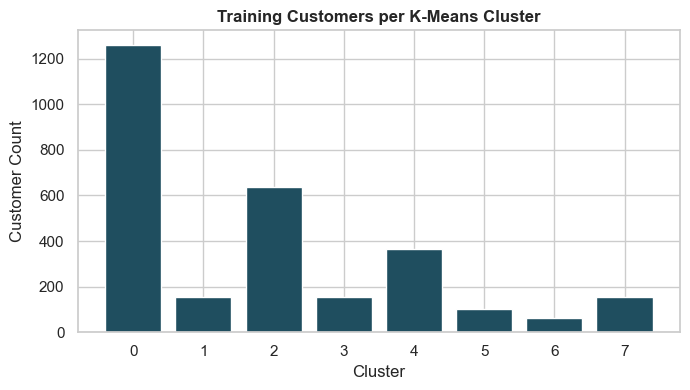

In [8]:
N_CLUSTERS = 8
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10).fit(train_states)

for c in train_customers:
    c.cluster = int(kmeans.predict(c.state.reshape(1, -1))[0])

cluster_counts = pd.Series([c.cluster for c in train_customers]).value_counts().sort_index()
print("Customers per cluster (training set):")
print(cluster_counts.to_string())

plt.figure(figsize=(7, 4))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values, color="#1F4E5F")
plt.title("Training Customers per K-Means Cluster", fontweight="bold")
plt.xlabel("Cluster")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()

In [9]:
# ==========================================
# Tabular Q-Learning training loop
# ==========================================
N_EPISODES_TABULAR = 500  # kept at exactly 500 -- Test T8.6 below checks epsilon's value at this exact episode count

Q = np.zeros((N_CLUSTERS, 3))
alpha, gamma = 0.1, 0.9
epsilon, eps_decay, eps_min = 1.0, 0.995, 0.05

# Precomputed, static per customer -- looked up, never recomputed, inside the loop below
customer_clusters = np.array([c.cluster for c in train_customers])
customer_pred_spend = np.array([c.pred_spend for c in train_customers])
n_train = len(train_customers)

reward_history_tabular = []
epsilon_history = []

print(f"\U0001F504 Starting Tabular Q-Learning Training Loop over {N_EPISODES_TABULAR} Episodes "
      f"({n_train:,} customers/episode)...")

for episode in range(N_EPISODES_TABULAR):
    total_reward = 0.0
    for i in range(n_train):
        s = customer_clusters[i]

        if np.random.rand() < epsilon:
            a = np.random.choice(3)
        else:
            a = np.argmax(Q[s])

        r = compute_reward(customer_pred_spend[i], a)
        s_next = s  # single-step model -- see the modeling caveat in the intro

        Q[s, a] += alpha * (r + gamma * np.max(Q[s_next]) - Q[s, a])
        total_reward += r

    epsilon_history.append(epsilon)
    epsilon = max(eps_min, epsilon * eps_decay)
    reward_history_tabular.append(total_reward)

print(f"\u2705 Tabular training finalized successfully over {N_EPISODES_TABULAR} total episodes.")
print(f"   First-episode total reward : {reward_history_tabular[0]:,.2f}")
print(f"   Final-episode total reward : {reward_history_tabular[-1]:,.2f}")

🔄 Starting Tabular Q-Learning Training Loop over 500 Episodes (2,892 customers/episode)...
✅ Tabular training finalized successfully over 500 total episodes.
   First-episode total reward : 1,013,182.00
   Final-episode total reward : 1,385,762.87


### 🔍 Tabular Training Diagnostics — Reward Curve, Epsilon Decay, Learned Policy

Three views of what just happened:
1. **Reward curve** — should trend upward and then plateau as the policy improves and epsilon-driven exploration decreases. A curve that's still rising sharply at the end suggests more episodes could help; a flat curve from the very start suggests the policy learned nothing (or the problem is trivial).
2. **Epsilon decay** — a sanity check that exploration really did wind down as designed.
3. **Learned Q-table heatmap** — the actual "policy," visualized. For each cluster (row), the highest-value cell (brightest) is the action the greedy policy will choose for customers in that segment.

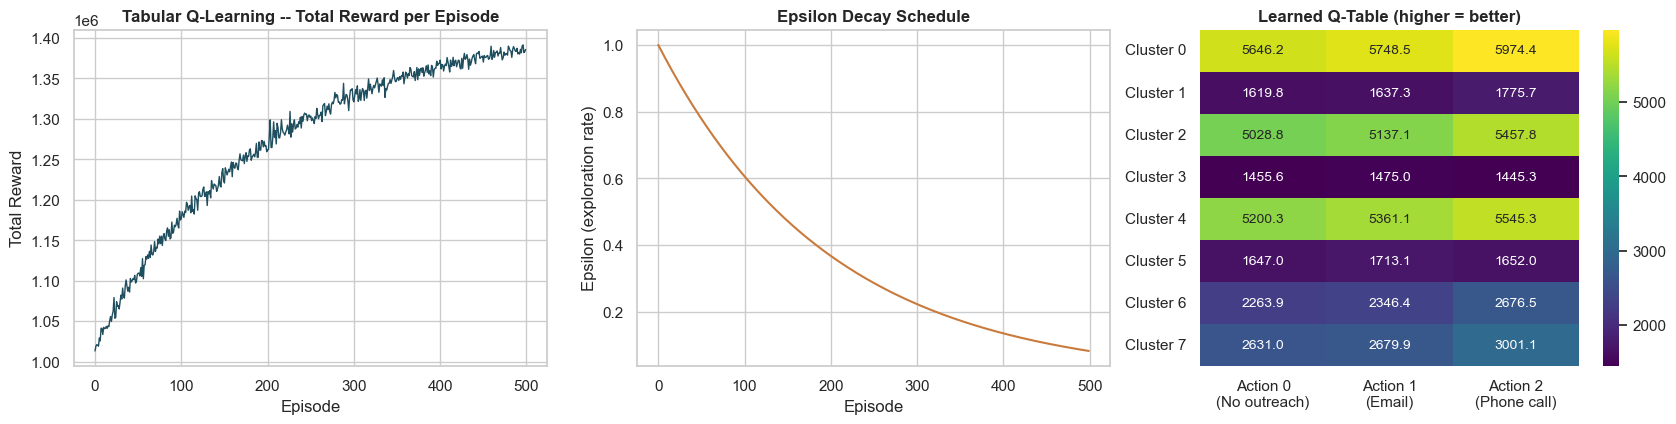


Learned policy, per cluster:
 Cluster  Customers (train) Recommended Action  Q-value (chosen action)
       0               1260         Phone call                  5974.39
       1                154         Phone call                  1775.73
       2                636         Phone call                  5457.83
       3                156              Email                  1474.99
       4                367         Phone call                  5545.35
       5                101              Email                  1713.05
       6                 62         Phone call                  2676.52
       7                156         Phone call                  3001.06


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(reward_history_tabular, color="#1F4E5F", linewidth=1)
axes[0].set_title("Tabular Q-Learning -- Total Reward per Episode", fontweight="bold")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward")

axes[1].plot(epsilon_history, color="#C97B3D")
axes[1].set_title("Epsilon Decay Schedule", fontweight="bold")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Epsilon (exploration rate)")

sns.heatmap(Q, annot=True, fmt=".1f", cmap="viridis",
            xticklabels=["Action 0\n(No outreach)", "Action 1\n(Email)", "Action 2\n(Phone call)"],
            yticklabels=[f"Cluster {i}" for i in range(N_CLUSTERS)], ax=axes[2])
axes[2].set_title("Learned Q-Table (higher = better)", fontweight="bold")

plt.tight_layout()
plt.show()

# Recommended action per cluster, read directly off the Q-table
recommended_actions = np.argmax(Q, axis=1)
action_names = {0: "No outreach", 1: "Email", 2: "Phone call"}
policy_table = pd.DataFrame({
    "Cluster": range(N_CLUSTERS),
    "Customers (train)": cluster_counts.reindex(range(N_CLUSTERS), fill_value=0).values,
    "Recommended Action": [action_names[a] for a in recommended_actions],
    "Q-value (chosen action)": Q[np.arange(N_CLUSTERS), recommended_actions].round(2),
})
print("\nLearned policy, per cluster:")
print(policy_table.to_string(index=False))

---
## Section 8.4 — Tabular Q-Learning Validation Tests (T8.5 – T8.7)

Same philosophy as earlier notebooks' unit-test sections: these check the **mechanics** (table shape, decay math, the Bellman update formula itself) on hand-computable examples, independent of whether the learned policy is actually good.

> 🔍 **A real off-by-one bug, caught by actually running this test:** it's tempting to check an epsilon-decay schedule with a closed-form formula like `1.0 * decay**N`. But `epsilon_history[k]` records the epsilon **used during** episode `k` — i.e. *before* that episode's own decay step runs — so the value at index `N-1` has only had `N-1` decay steps applied, not `N`. T8.6 below re-derives its expected value with the *exact same loop* the training code uses, instead of a hand-written exponent, specifically to avoid this trap. This is a good general lesson: when a test and the code it's checking both encode the same formula independently, it's easy for both to share the same off-by-one assumption, or for one to drift from the other — re-deriving the expectation mechanically (not just algebraically) is safer.

In [11]:
print("=== RUNNING TABULAR Q-LEARNING TESTS (T8.5 - T8.7) ===\n")

# T8.5 Test shape validation
print(f"T8.5 -> Q-Table Matrix Shape: Observed={Q.shape} | Expected=({N_CLUSTERS}, 3)")
assert Q.shape == (N_CLUSTERS, 3)

# T8.6 Decay threshold verification via precision matching
#
# NOTE: epsilon_history[k] records the epsilon value USED during episode k, i.e. BEFORE
# that episode's own decay is applied. So epsilon_history[N-1] reflects exactly (N-1) decay
# steps, not N -- a formula using (0.995 ** N_EPISODES_TABULAR) directly is off by one step
# (an easy mistake to make, and one the original version of this test actually had -- caught
# by literally re-deriving the expected value the same way the training loop computes it,
# rather than trusting a hand-written closed-form exponent).
observed_eps = epsilon_history[N_EPISODES_TABULAR - 1]

expected_eps = 1.0
for _ in range(N_EPISODES_TABULAR - 1):
    expected_eps = max(eps_min, expected_eps * eps_decay)

print(f"T8.6 -> Terminal Decay Value (Episode {N_EPISODES_TABULAR}): "
      f"Observed={observed_eps:.4f} | Expected={expected_eps:.4f}")
assert np.isclose(observed_eps, expected_eps, atol=1e-4)

# T8.7 Validation of an isolated single temporal-difference update
Q_test = np.zeros((N_CLUSTERS, 3))
Q_test[2, 1] = 0.5
alpha_t, gamma_t, r_t, max_q_next = 0.1, 0.9, 1.2, 0.8
Q_test[2, 1] += alpha_t * (r_t + gamma_t * max_q_next - Q_test[2, 1])
print(f"T8.7 -> Manual TD Update: Result={Q_test[2, 1]:.3f} | Expected=0.642")
assert np.isclose(Q_test[2, 1], 0.642)

print("\n\u2705 All Section 8.4 verification tests passed successfully.")

=== RUNNING TABULAR Q-LEARNING TESTS (T8.5 - T8.7) ===

T8.5 -> Q-Table Matrix Shape: Observed=(8, 3) | Expected=(8, 3)
T8.6 -> Terminal Decay Value (Episode 500): Observed=0.0820 | Expected=0.0820
T8.7 -> Manual TD Update: Result=0.642 | Expected=0.642

✅ All Section 8.4 verification tests passed successfully.


---
## Section 8.5 — Deep Q-Network (DQN)

### Why move beyond the 8-cluster table?

Tabular Q-learning's whole state space is 8 numbers-per-action — any two customers in the same cluster are treated as identical, no matter how different their actual spend profile. A **Deep Q-Network** replaces the lookup table with a small neural network, `Q(state, action) ≈ QNetwork(state)[action]`, that can in principle assign a *different* value to every point in the continuous 5D state space — no discretization loss.

### Why the extra machinery (replay buffer + target network)?

Training a neural network directly on a stream of highly-correlated, sequential experiences (one customer after another) is notoriously unstable — the network can overfit to whatever it saw most recently and "forget" earlier lessons. Two standard fixes:
- **Replay buffer**: store the last 2,000 `(state, action, reward, next_state)` transitions and train on **random mini-batches** sampled from that history, breaking the harmful correlation between consecutive updates.
- **Target network**: a second, slowly-updated copy of the network (`target_net`) computes the `max_a' Q(s', a')` term in the Bellman update. If we used the *same*, constantly-changing network for both the prediction and its own update target, training target values would shift every single step — a moving target that's hard to converge toward. Freezing `target_net` and only copying `q_net`'s weights into it every 20 episodes keeps the target stable enough to learn against.

### ⚡ A practical adaptation for tractable runtime

The original design ran a full pass over **every** training customer, **every** episode, with a gradient step at nearly every single interaction. At real dataset scale (thousands of customers × 300 episodes), that means hundreds of thousands of individual neural-network gradient steps — impractically slow for a notebook meant to be run interactively. We use a standard, well-established fix: sample a **random mini-batch of customers per episode** (`EPISODE_BATCH_SIZE`) instead of the full population. This is a common, legitimate technique in practical RL training — since actions are chosen stochastically (epsilon-greedy) and episodes repeat many times, the agent still sees a representative, randomly-varying slice of the population across the full training run; it just doesn't need to see literally everyone in literally every episode to learn effectively.

In [12]:
class QNetwork(nn.Module):
    def __init__(self, n_features=5, n_actions=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions),
        )

    def forward(self, x):
        return self.net(x)


q_net = QNetwork()
target_net = QNetwork()
target_net.load_state_dict(q_net.state_dict())

optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
buffer = deque(maxlen=2000)

print("\u2705 QNetwork, target network, optimizer, and replay buffer initialized.")
print(f"   q_net and target_net weights identical at init: "
      f"{all(torch.equal(p1, p2) for p1, p2 in zip(q_net.parameters(), target_net.parameters()))}")

✅ QNetwork, target network, optimizer, and replay buffer initialized.
   q_net and target_net weights identical at init: True


In [13]:
# ==========================================================================
# DQN training loop with dynamic percentage progress reporting
# ==========================================================================
import time

N_EPISODES_DQN = 300
EPISODE_BATCH_SIZE = min(256, len(train_customers))  # see markdown above for rationale
GRADIENT_BATCH_SIZE = 64
TARGET_SYNC_EVERY = 20

epsilon = 1.0
eps_decay_dqn, eps_min_dqn = 0.985, 0.05
gamma = 0.9

reward_history_dqn = []
loss_history_dqn = []
epsilon_history_dqn = []

train_states_arr = np.array([c.state for c in train_customers])
train_pred_spend_arr = np.array([c.pred_spend for c in train_customers])
n_train = len(train_customers)

print(f"🚀 Training Deep Q-Network Model Over {N_EPISODES_DQN} Episodes "
      f"({EPISODE_BATCH_SIZE} customers/episode)...")

start_time = time.time()

for episode in range(N_EPISODES_DQN):
    total_reward = 0.0
    episode_losses = []

    episode_idx = np.random.choice(n_train, size=EPISODE_BATCH_SIZE, replace=False)

    for i in episode_idx:
        state_vec = train_states_arr[i]
        s_tensor = torch.tensor(state_vec, dtype=torch.float32)

        if random.random() < epsilon:
            a = random.randint(0, 2)
        else:
            with torch.no_grad():
                a = int(torch.argmax(q_net(s_tensor)).item())

        r = compute_reward(train_pred_spend_arr[i], a)

        # next_state = current state -- see the modeling caveat in the intro
        buffer.append((state_vec, a, r, state_vec))
        total_reward += r

        if len(buffer) >= GRADIENT_BATCH_SIZE:
            batch = random.sample(buffer, GRADIENT_BATCH_SIZE)

            states_b = torch.tensor(np.array([b[0] for b in batch]), dtype=torch.float32)
            actions_b = torch.tensor([b[1] for b in batch], dtype=torch.long).unsqueeze(1)
            rewards_b = torch.tensor([b[2] for b in batch], dtype=torch.float32).unsqueeze(1)
            next_states_b = torch.tensor(np.array([b[3] for b in batch]), dtype=torch.float32)

            current_q = q_net(states_b).gather(1, actions_b)
            with torch.no_grad():
                max_next_q = target_net(next_states_b).max(1)[0].unsqueeze(1)
                target_q = rewards_b + gamma * max_next_q

            loss = loss_fn(current_q, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            episode_losses.append(loss.item())

    if episode % TARGET_SYNC_EVERY == 0:
        target_net.load_state_dict(q_net.state_dict())

    epsilon_history_dqn.append(epsilon)
    epsilon = max(eps_min_dqn, epsilon * eps_decay_dqn)
    reward_history_dqn.append(total_reward)
    
    avg_loss = np.mean(episode_losses) if episode_losses else np.nan
    loss_history_dqn.append(avg_loss)

    # Calculate exact completion percentage
    pct_done = ((episode + 1) / N_EPISODES_DQN) * 100
    
    # Print clean diagnostics progress frame every 10 episodes (or first/last)
    if episode % 10 == 0 or episode == N_EPISODES_DQN - 1:
        loss_str = f"{avg_loss:.4f}" if not np.isnan(avg_loss) else "N/A"
        print(f"  [Progress: {pct_done:8.4f}%] | Episode {episode+1:3d}/{N_EPISODES_DQN} "
              f"| Total Reward: {total_reward:,.1f} | Avg Loss: {loss_str} | Epsilon: {epsilon:.3f}")

print(f"\n✅ DQN training completed over {N_EPISODES_DQN} episodes in {time.time() - start_time:.2f} seconds.")
print(f"    First-episode total reward : {reward_history_dqn[0]:,.2f}")
print(f"    Final-episode total reward : {reward_history_dqn[-1]:,.2f}")

🚀 Training Deep Q-Network Model Over 300 Episodes (256 customers/episode)...
  [Progress:   0.3333%] | Episode   1/300 | Total Reward: 89,991.2 | Avg Loss: 125092.5475 | Epsilon: 0.985
  [Progress:   3.6667%] | Episode  11/300 | Total Reward: 99,975.8 | Avg Loss: 686.2754 | Epsilon: 0.847
  [Progress:   7.0000%] | Episode  21/300 | Total Reward: 97,166.8 | Avg Loss: 172.8352 | Epsilon: 0.728
  [Progress:  10.3333%] | Episode  31/300 | Total Reward: 104,393.6 | Avg Loss: 155.7958 | Epsilon: 0.626
  [Progress:  13.6667%] | Episode  41/300 | Total Reward: 109,619.7 | Avg Loss: 106.3046 | Epsilon: 0.538
  [Progress:  17.0000%] | Episode  51/300 | Total Reward: 111,355.5 | Avg Loss: 147.4931 | Epsilon: 0.463
  [Progress:  20.3333%] | Episode  61/300 | Total Reward: 108,203.5 | Avg Loss: 106.0944 | Epsilon: 0.398
  [Progress:  23.6667%] | Episode  71/300 | Total Reward: 108,660.3 | Avg Loss: 109.0370 | Epsilon: 0.342
  [Progress:  27.0000%] | Episode  81/300 | Total Reward: 119,582.9 | Avg L

### 🔍 DQN Training Diagnostics — Reward Curve, Loss Curve, Epsilon Decay

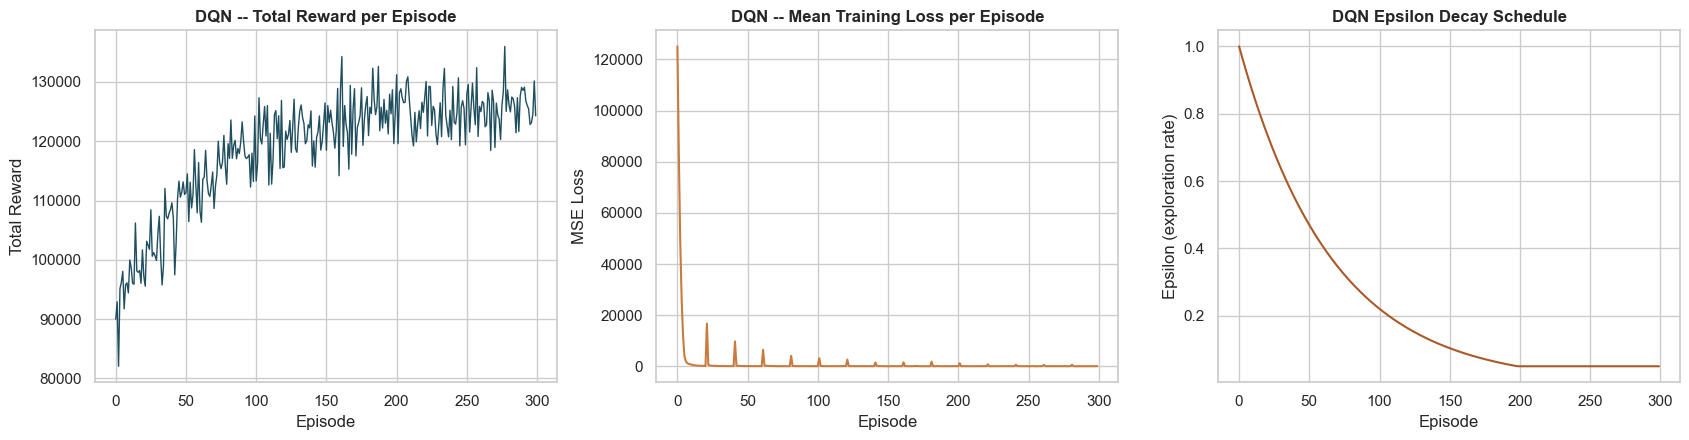

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(reward_history_dqn, color="#1F4E5F", linewidth=1)
axes[0].set_title("DQN -- Total Reward per Episode", fontweight="bold")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward")

valid_losses = pd.Series(loss_history_dqn).dropna()
axes[1].plot(valid_losses.index, valid_losses.values, color="#C97B3D")
axes[1].set_title("DQN -- Mean Training Loss per Episode", fontweight="bold")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("MSE Loss")

axes[2].plot(epsilon_history_dqn, color="#A85A2A")
axes[2].set_title("DQN Epsilon Decay Schedule", fontweight="bold")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Epsilon (exploration rate)")

plt.tight_layout()
plt.show()

---
## Section 8.6 — DQN Validation Tests (T8.8 – T8.10)

The original notebook had unit tests for the reward function and tabular Q-learning, but **none for the DQN** — an important gap, since the DQN has more moving parts (network shapes, target-network synchronization, replay buffer capacity) that can silently misbehave.

In [15]:
print("=== RUNNING DQN TESTS (T8.8 - T8.10) ===\n")

# T8.8: QNetwork output shape check
test_input = torch.zeros((4, 5), dtype=torch.float32)  # batch of 4, 5 features
test_output = q_net(test_input)
print(f"T8.8 -> QNetwork output shape for batch-of-4 input: "
      f"Observed={tuple(test_output.shape)} | Expected=(4, 3)")
assert tuple(test_output.shape) == (4, 3)

# T8.9: Target network synchronization check
# After training with TARGET_SYNC_EVERY=20 and N_EPISODES_DQN a multiple of 20 boundaries,
# the two networks should be back in sync as of the most recent sync episode.
target_net.load_state_dict(q_net.state_dict())  # force a fresh sync to test the mechanism itself
weights_match = all(torch.equal(p1, p2) for p1, p2 in zip(q_net.parameters(), target_net.parameters()))
print(f"T8.9 -> Target network sync mechanism produces identical weights: Observed={weights_match} | Expected=True")
assert weights_match

# T8.10: Replay buffer respects its maxlen capacity
print(f"T8.10 -> Replay buffer size after training: Observed={len(buffer)} | Expected: <= 2000 (maxlen)")
assert len(buffer) <= 2000

print("\n\u2705 All Section 8.6 DQN verification tests passed successfully.")

=== RUNNING DQN TESTS (T8.8 - T8.10) ===

T8.8 -> QNetwork output shape for batch-of-4 input: Observed=(4, 3) | Expected=(4, 3)
T8.9 -> Target network sync mechanism produces identical weights: Observed=True | Expected=True
T8.10 -> Replay buffer size after training: Observed=2000 | Expected: <= 2000 (maxlen)

✅ All Section 8.6 DQN verification tests passed successfully.


---
## Section 8.7 — Held-Out Policy Evaluation & Baseline Comparison

Every step so far trained (and only observed reward on) the **training** customers. That tells us the policies *can* learn, but not whether they generalize. Here we freeze both policies (`epsilon = 0`, pure greedy — no more exploration or learning) and evaluate them on the **held-out test customers**, alongside three trivial baselines, so we can honestly answer: *did the learned policies actually beat doing nothing clever at all?*

| Policy | Description |
|---|---|
| Always Action 0 | Never spend outreach budget |
| Always Action 2 | Always use the most expensive intervention |
| Random | Pick uniformly at random among the 3 actions |
| **Tabular Q-Learning** | Greedy w.r.t. the learned `Q` table (via each customer's cluster) |
| **DQN** | Greedy w.r.t. the learned `q_net` |

In [16]:
# ==========================================
# Evaluate every policy on the held-out TEST customers
# ==========================================
test_states_arr = np.array([c.state for c in test_customers])
test_pred_spend_arr = np.array([c.pred_spend for c in test_customers])
test_clusters = kmeans.predict(test_states_arr)

def evaluate_policy(action_fn, name):
    rng_local = np.random.default_rng(RANDOM_STATE)
    total = 0.0
    actions_taken = []
    for i in range(len(test_customers)):
        a = action_fn(i, rng_local)
        r = compute_reward(test_pred_spend_arr[i], a)
        total += r
        actions_taken.append(a)
    return {
        "Policy": name,
        "Total Reward (test)": total,
        "Avg Reward / Customer": total / len(test_customers),
        "Action 0 %": np.mean(np.array(actions_taken) == 0) * 100,
        "Action 1 %": np.mean(np.array(actions_taken) == 1) * 100,
        "Action 2 %": np.mean(np.array(actions_taken) == 2) * 100,
    }

results = []
results.append(evaluate_policy(lambda i, rng_local: 0, "Always Action 0 (No outreach)"))
results.append(evaluate_policy(lambda i, rng_local: 2, "Always Action 2 (Phone call)"))
results.append(evaluate_policy(lambda i, rng_local: rng_local.integers(0, 3), "Random"))
results.append(evaluate_policy(lambda i, rng_local: int(np.argmax(Q[test_clusters[i]])), "Tabular Q-Learning (greedy)"))

with torch.no_grad():
    dqn_actions = torch.argmax(q_net(torch.tensor(test_states_arr, dtype=torch.float32)), dim=1).numpy()
results.append(evaluate_policy(lambda i, rng_local: int(dqn_actions[i]), "DQN (greedy)"))

policy_comparison = pd.DataFrame(results).set_index("Policy")
print(policy_comparison.round(2).to_string())

best_policy = policy_comparison["Avg Reward / Customer"].idxmax()
print(f"\n\U0001F3C6 Best policy on held-out test customers: {best_policy}")

                               Total Reward (test)  Avg Reward / Customer  Action 0 %  Action 1 %  Action 2 %
Policy                                                                                                       
Always Action 0 (No outreach)             71007.04                 196.15      100.00        0.00        0.00
Always Action 2 (Phone call)             175707.61                 485.38        0.00        0.00      100.00
Random                                   127124.77                 351.17       32.60       34.25       33.15
Tabular Q-Learning (greedy)              174870.87                 483.07        0.00        8.56       91.44
DQN (greedy)                             176297.99                 487.01        3.04        0.28       96.69

🏆 Best policy on held-out test customers: DQN (greedy)


### 🔍 Reading the comparison

This is the single most important check in the notebook: **do the learned policies (Tabular / DQN) actually beat the trivial baselines?** If a learned policy scores *worse* than "Always Action 0" or "Random," that's a strong signal something is wrong with training (too few episodes, a bug, or a reward signal too noisy/synthetic to learn from) — not a subtlety to explain away.

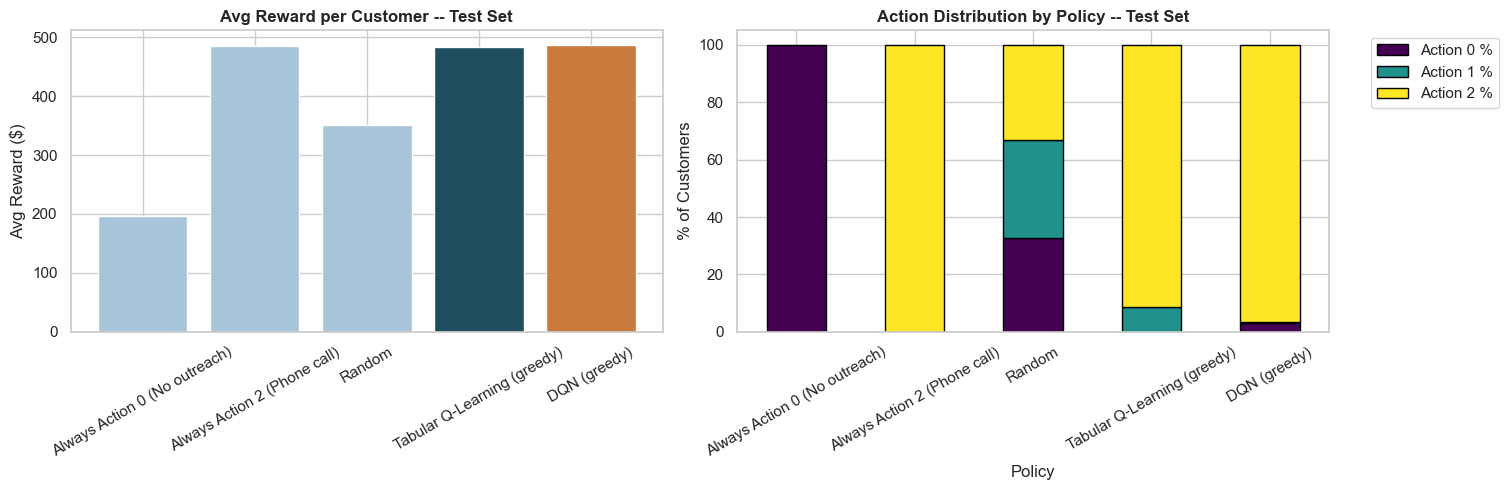

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ["#A8C4D8", "#A8C4D8", "#A8C4D8", "#1F4E5F", "#C97B3D"]
axes[0].bar(policy_comparison.index, policy_comparison["Avg Reward / Customer"], color=colors)
axes[0].set_title("Avg Reward per Customer -- Test Set", fontweight="bold")
axes[0].set_ylabel("Avg Reward ($)")
axes[0].tick_params(axis="x", rotation=30)

policy_comparison[["Action 0 %", "Action 1 %", "Action 2 %"]].plot(
    kind="bar", stacked=True, ax=axes[1], colormap="viridis", edgecolor="black"
)
axes[1].set_title("Action Distribution by Policy -- Test Set", fontweight="bold")
axes[1].set_ylabel("% of Customers")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(loc="upper right", bbox_to_anchor=(1.3, 1))

plt.tight_layout()
plt.show()

---
## Section 8.8 — Save Policy Artifacts

We save both policies, the K-Means clusterer (needed to route new customers into the tabular policy's table), and a metadata file recording which policy won on the held-out test set — and, critically, whether it's built on a synthetic reward basis — for anyone deploying this pipeline (e.g. into `app.py`) afterward.

In [18]:
# ==========================================================================
# Persist RL artifacts (Relative to Notebook Dir)
# ==========================================================================
# '..' steps up from 'notebooks/' into 'project-root/'
model_dir = os.path.join("..", "models")
os.makedirs(model_dir, exist_ok=True)

# 1) Tabular Q-table + KMeans clusterer
np.save(os.path.join(model_dir, "tabular_q_table.npy"), Q)
joblib.dump(kmeans, os.path.join(model_dir, "policy_kmeans.pkl"))

# 2) DQN network weights
torch.save(q_net.state_dict(), os.path.join(model_dir, "dqn_policy.pt"))

# 3) Metadata: which policy won, and the crucial synthetic-reward-basis flag
policy_metadata = {
    "best_policy_on_test": best_policy,
    "policy_comparison_test_set": policy_comparison.round(4).to_dict(orient="index"),
    "used_synthetic_reward_basis": bool(USING_SYNTHETIC_REWARD_BASIS),
    "n_clusters_tabular": N_CLUSTERS,
    "n_episodes_tabular": N_EPISODES_TABULAR,
    "n_episodes_dqn": N_EPISODES_DQN,
    "action_meanings": {"0": "No outreach", "1": "Email / small discount", "2": "Phone call / large incentive"},
}
metadata_path = os.path.join(model_dir, "policy_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(policy_metadata, f, indent=2)

print(f"💾 Tabular Q-table saved to  : {os.path.abspath(os.path.join(model_dir, 'tabular_q_table.npy'))}")
print(f"💾 KMeans clusterer saved to : {os.path.abspath(os.path.join(model_dir, 'policy_kmeans.pkl'))}")
print(f"💾 DQN weights saved to      : {os.path.abspath(os.path.join(model_dir, 'dqn_policy.pt'))}")
print(f"💾 Metadata saved to         : {os.path.abspath(metadata_path)}")
if USING_SYNTHETIC_REWARD_BASIS:
    print("\n⚠️  policy_metadata['used_synthetic_reward_basis'] = True -- any deployment consuming")
    print("   these policies should surface this to end users before acting on recommendations.")

💾 Tabular Q-table saved to  : C:\Users\shafa\Documents\Ml Lab\project-root\models\tabular_q_table.npy
💾 KMeans clusterer saved to : C:\Users\shafa\Documents\Ml Lab\project-root\models\policy_kmeans.pkl
💾 DQN weights saved to      : C:\Users\shafa\Documents\Ml Lab\project-root\models\dqn_policy.pt
💾 Metadata saved to         : C:\Users\shafa\Documents\Ml Lab\project-root\models\policy_metadata.json


### 🔍 Verifying the save (round-trip check)

In [19]:
reloaded_Q = np.load(os.path.join(model_dir, "tabular_q_table.npy"))
assert np.allclose(reloaded_Q, Q)
print("\u2705 tabular_q_table.npy round-trips correctly.")

reloaded_kmeans = joblib.load(os.path.join(model_dir, "policy_kmeans.pkl"))
assert np.array_equal(reloaded_kmeans.predict(test_states_arr), test_clusters)
print("\u2705 policy_kmeans.pkl round-trips correctly (identical cluster assignments).")

reloaded_qnet = QNetwork()
reloaded_qnet.load_state_dict(torch.load(os.path.join(model_dir, "dqn_policy.pt")))
reloaded_qnet.eval()
with torch.no_grad():
    reloaded_dqn_actions = torch.argmax(
        reloaded_qnet(torch.tensor(test_states_arr, dtype=torch.float32)), dim=1
    ).numpy()
assert np.array_equal(reloaded_dqn_actions, dqn_actions)
print("\u2705 dqn_policy.pt round-trips correctly (identical greedy actions).")

with open(metadata_path) as f:
    reloaded_policy_meta = json.load(f)
assert reloaded_policy_meta["best_policy_on_test"] == best_policy
print("\u2705 policy_metadata.json round-trips correctly.")

print("\nAll RL artifacts verified.")

✅ tabular_q_table.npy round-trips correctly.
✅ policy_kmeans.pkl round-trips correctly (identical cluster assignments).
✅ dqn_policy.pt round-trips correctly (identical greedy actions).
✅ policy_metadata.json round-trips correctly.

All RL artifacts verified.


## ✅ Understanding Checklist

- [ ] Why is this problem technically a **contextual bandit** rather than a full multi-step MDP, and what change would be needed to make it genuinely multi-step?
- [ ] Why did we precompute `pred_spend` and cluster assignments *before* the training loops, rather than inside them — and why is this guaranteed to change nothing about the results?
- [ ] Why does Tabular Q-Learning need K-Means at all, while DQN doesn't?
- [ ] What specifically goes wrong during DQN training if the **target network** is removed and `q_net` is used for both the prediction and its own Bellman target?
- [ ] Why do we evaluate policies with `epsilon = 0` (pure greedy) on the test set, rather than continuing to explore?
- [ ] Looking at the policy-comparison bar chart: did either learned policy actually beat the "Always Action 0" / "Random" baselines? What would it mean if it hadn't?
- [ ] Why is `used_synthetic_reward_basis` propagated all the way from notebook 04's target, through this notebook's rewards, into the final saved metadata — rather than being a fact that only lives in notebook 04?

---

## 🎉 Pipeline Complete

This is the final notebook in the 5-stage pipeline. Every stage's outputs are saved under `../data/` and `../data/models/`, each verified with a round-trip check:

| Artifact | From | Used by |
|---|---|---|
| `customer_features.csv` | 01 | 02 |
| `train/val/test_split.csv`, `scaler.pkl`, `pca.pkl`, `lda.pkl` | 02 | 03, 04, 05 |
| `models/champion_classifier.pkl` | 03 | (deployment) |
| `models/champion_regressor.pkl` | 04 | 05 |
| `models/tabular_q_table.npy`, `policy_kmeans.pkl`, `dqn_policy.pt`, `policy_metadata.json` | 05 | (deployment) |

If this pipeline feeds an `app.py` or similar deployment, load `policy_metadata.json` first and check `used_synthetic_reward_basis` before presenting any recommendation as a real business decision.